<a href="https://colab.research.google.com/github/pragnyavaleti/2520030238_ML/blob/main/Skill/Week_6_dataScaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load data
df = pd.read_csv("titanic_cleaned.csv")

# Drop unnecessary columns
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

# Separate features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Select columns
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

# Define transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Apply transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Fit and transform the data
X_preprocessed = preprocessor.fit_transform(X)

print("Shape after preprocessing:", X_preprocessed.shape)


Shape after preprocessing: (891, 12)


In [7]:
# Get feature names after one-hot encoding
cat_columns = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_columns = numeric_features + list(cat_columns)

# Convert to DataFrame for better readability
X_preprocessed_df = pd.DataFrame(X_preprocessed.toarray() if hasattr(X_preprocessed, "toarray") else X_preprocessed,
                                 columns=all_columns)

# Display the first few rows
print(X_preprocessed_df.head())

        Age     SibSp     Parch      Fare  Pclass_1  Pclass_2  Pclass_3  \
0 -0.565736  0.432793 -0.473674 -0.502445       0.0       0.0       1.0   
1  0.663861  0.432793 -0.473674  0.786845       1.0       0.0       0.0   
2 -0.258337 -0.474545 -0.473674 -0.488854       0.0       0.0       1.0   
3  0.433312  0.432793 -0.473674  0.420730       1.0       0.0       0.0   
4  0.433312 -0.474545 -0.473674 -0.486337       0.0       0.0       1.0   

   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  
0         0.0       1.0         0.0         0.0         1.0  
1         1.0       0.0         1.0         0.0         0.0  
2         1.0       0.0         0.0         0.0         1.0  
3         1.0       0.0         0.0         0.0         1.0  
4         0.0       1.0         0.0         0.0         1.0  


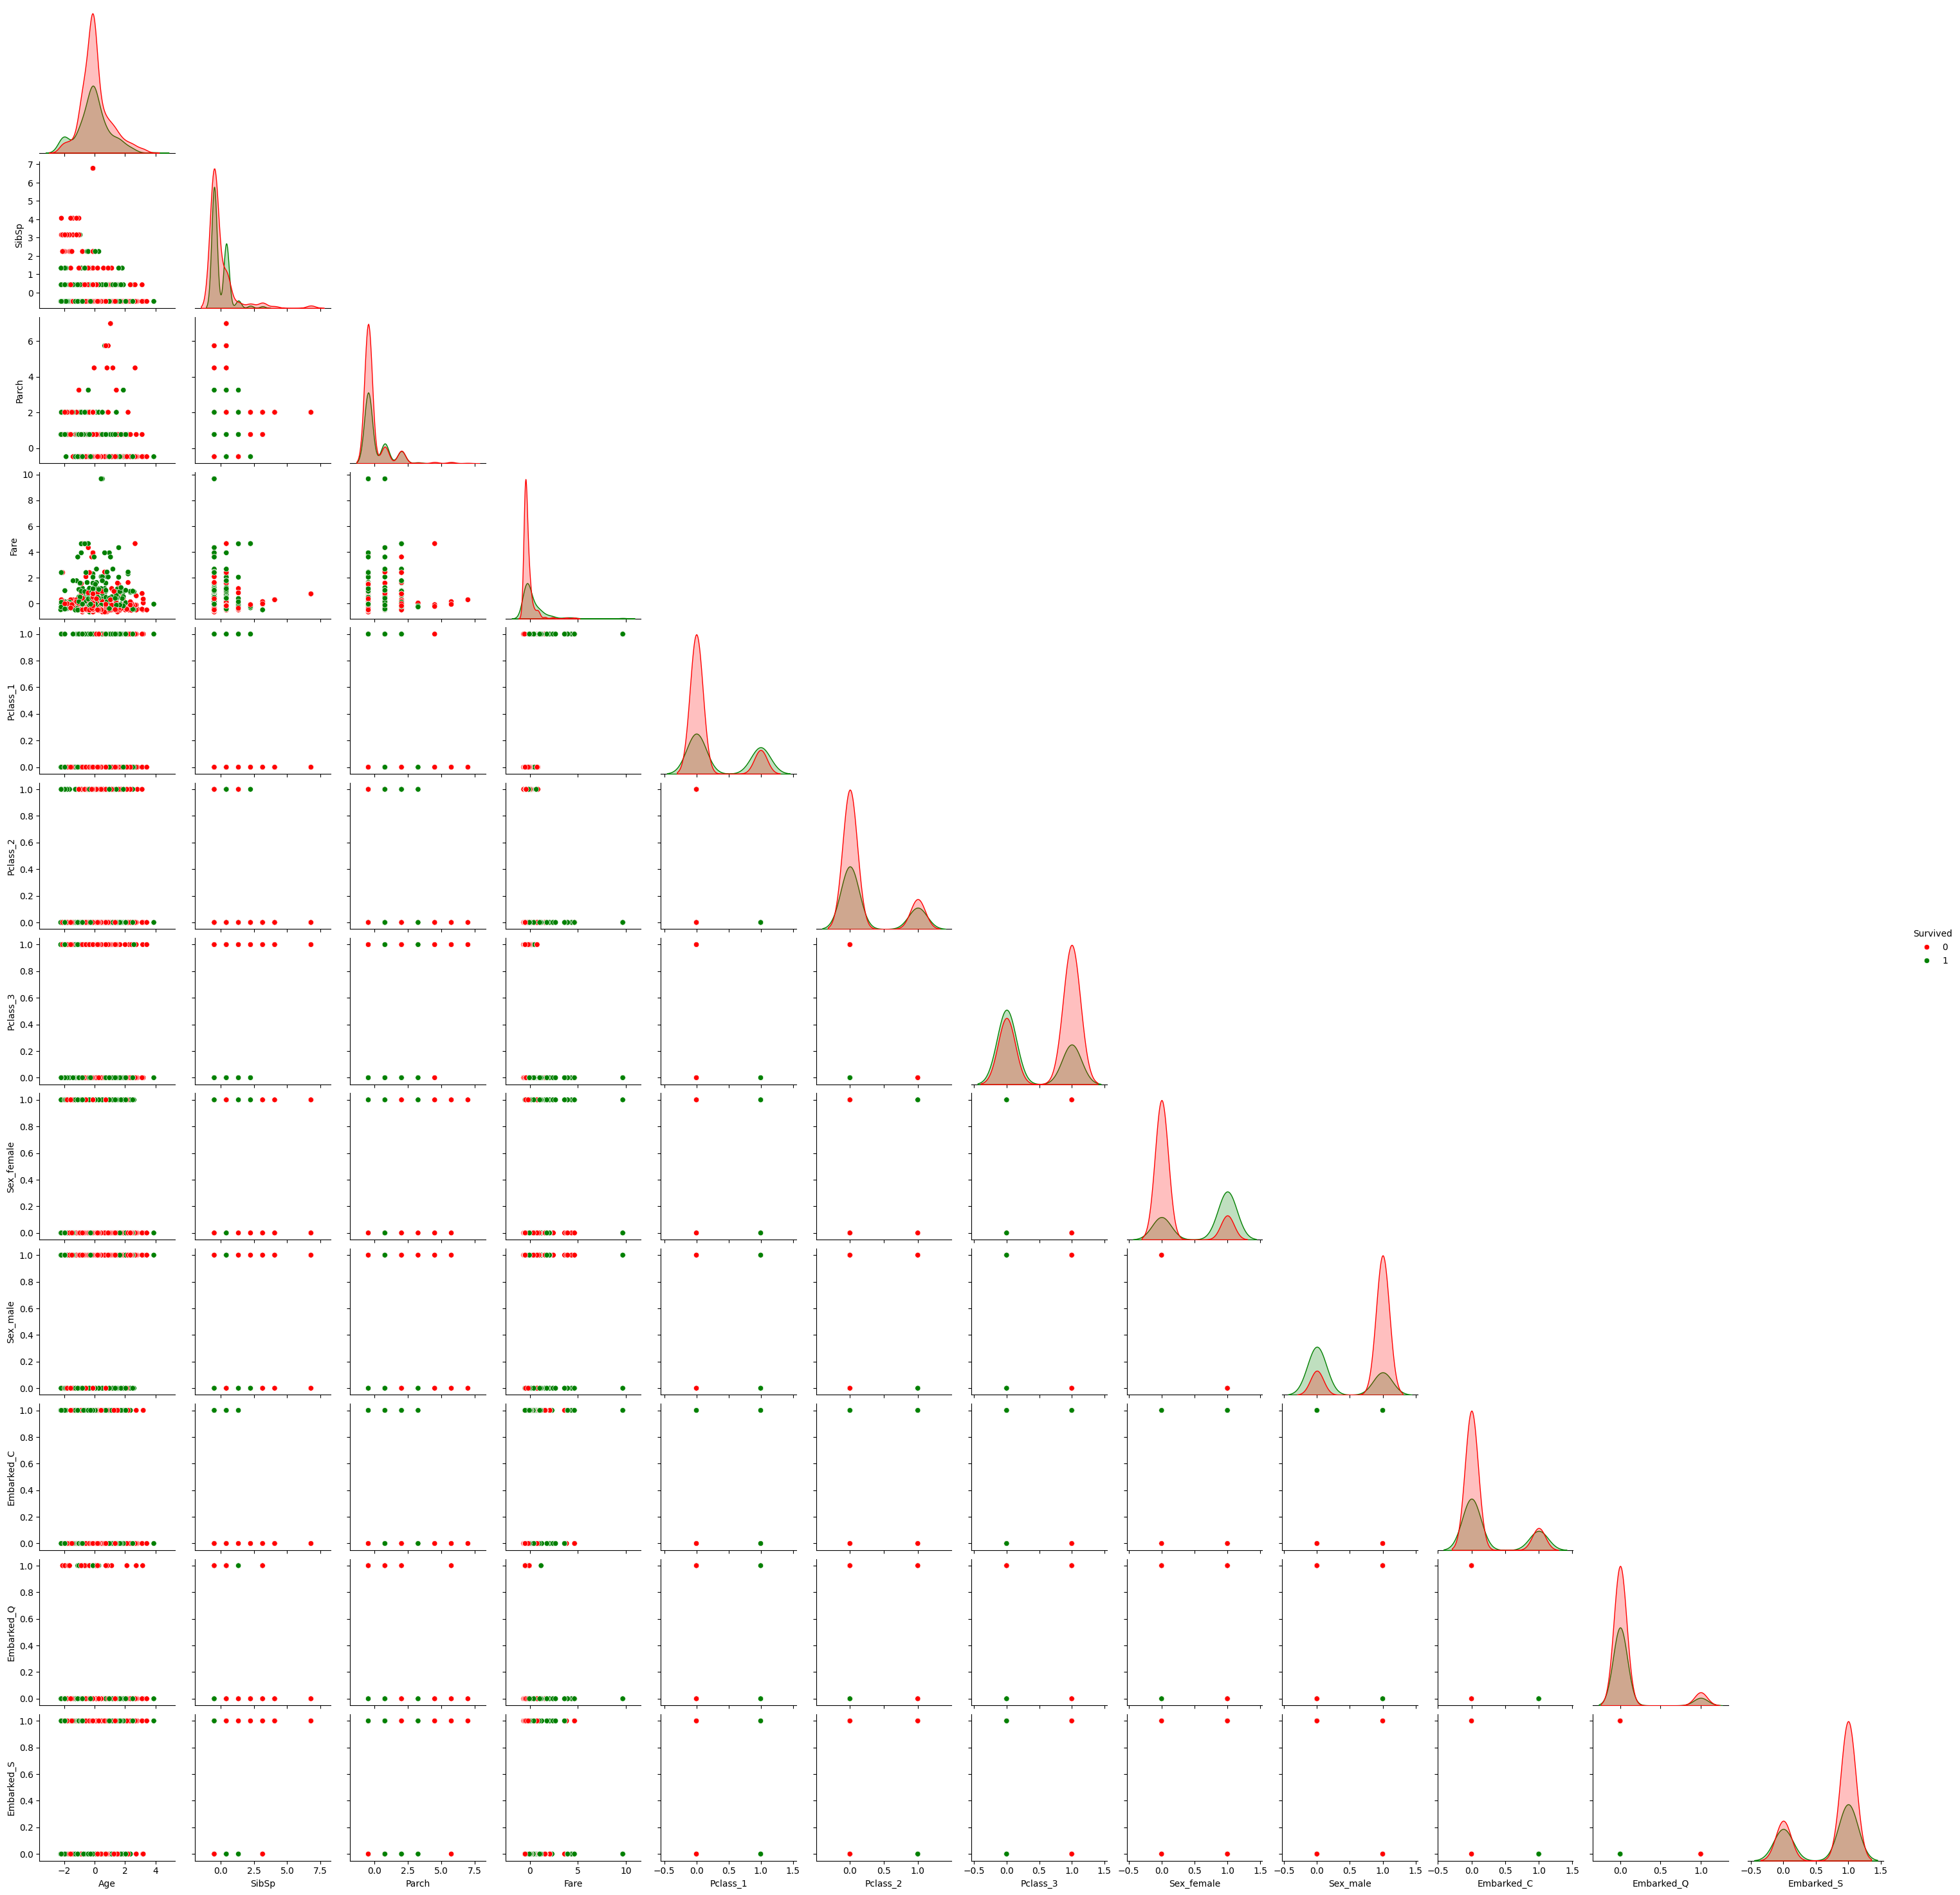

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Since X_preprocessed_df is fully numeric after one-hot encoding,
# we can add the target column back for visualization
X_preprocessed_df['Survived'] = y.values

# Pair plot
sns.pairplot(X_preprocessed_df, hue='Survived', corner=True,
             palette={0: "red", 1: "green"})
plt.show()


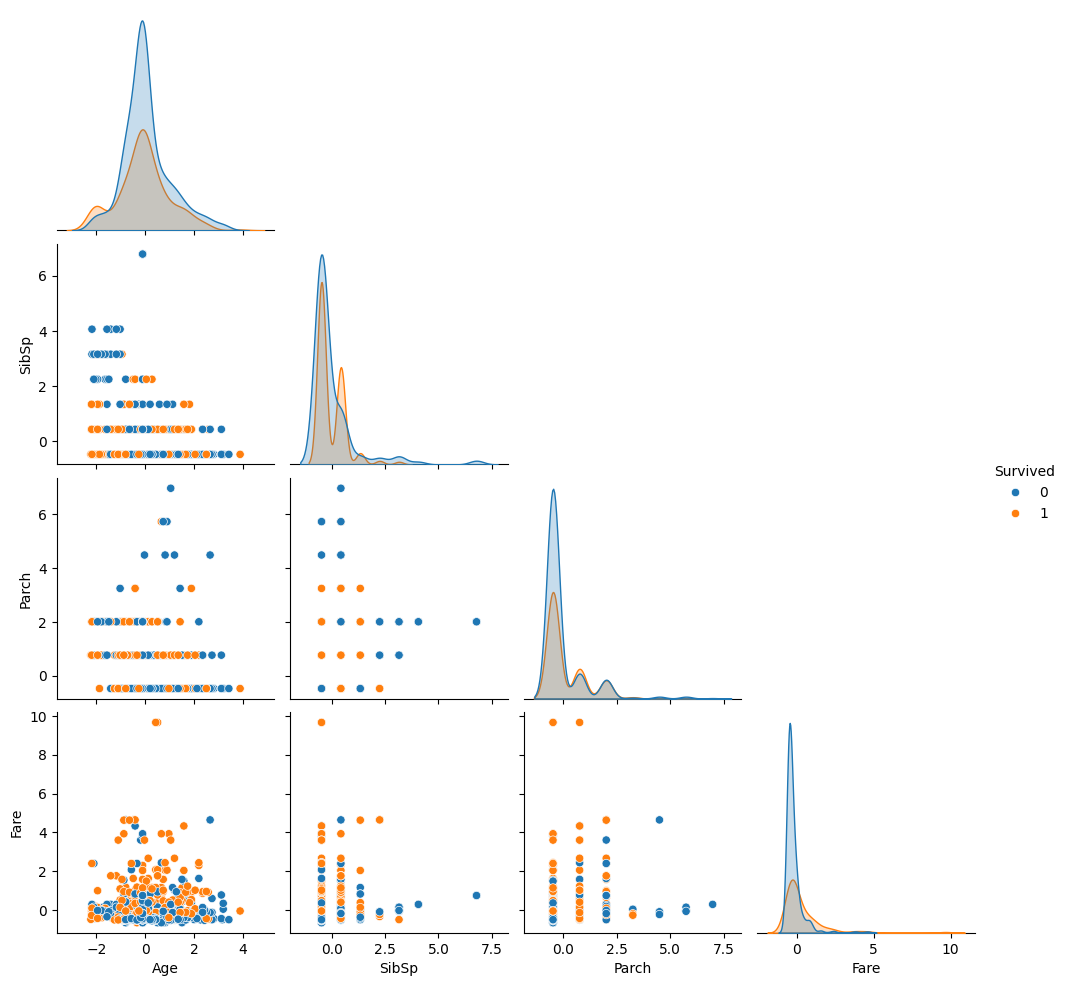

In [9]:
#Numeric Pair Plot
numeric_cols = ["Age", "SibSp", "Parch", "Fare"]
sns.pairplot(X_preprocessed_df[numeric_cols + ['Survived']], hue='Survived', corner=True)
plt.show()


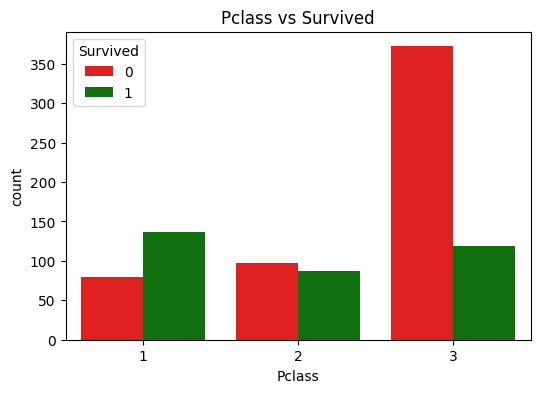

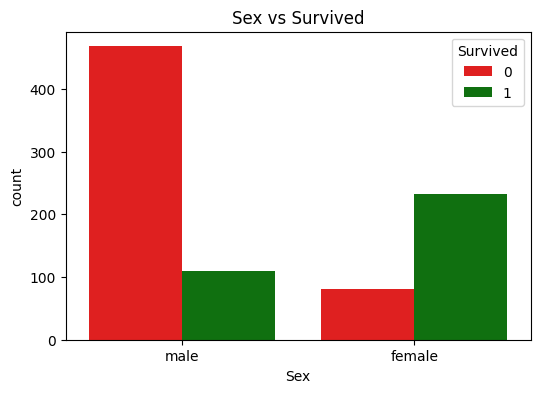

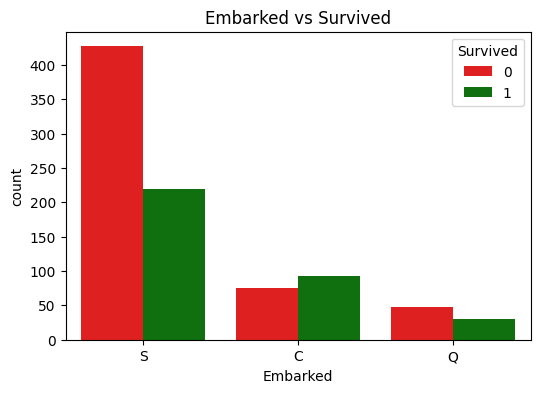

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Original categorical data
cat_features = ["Pclass", "Sex", "Embarked"]

# Add target back
df_cat = X[cat_features].copy()
df_cat['Survived'] = y.values

# Plot categorical features vs Survived
for feature in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=feature, hue='Survived', data=df_cat, palette={0:"red",1:"green"})
    plt.title(f"{feature} vs Survived")
    plt.show()
